# Shock Tube Data Explorer
Deep dive into the normalized `.pt` files to verify data integrity before training.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

DATA_DIR = Path('/standard/sds_baek_energetic/PSAAP - SAGEST/Chord_ShockTube_0.5x0.5mDomain_64x64Cells/different_dt/normalized_datasets')
TRAIN_DIR = DATA_DIR / 'train_cases_normalized'
META_FILE = DATA_DIR / 'normalization_metadata.json'

with open(META_FILE) as f:
    meta = json.load(f)

print("=== Normalization Method ===")
print(f"  Method: {meta['normalization_method']}")
print(f"  Dataset version: {meta['dataset_version']}")
print(f"  Parameters normalized: {meta['parameters_normalized']}")
print(f"  Parameters location: {meta['parameters_location']}")

print("\n=== Feature Layout ===")
print(f"  x features: {meta['feature_layout']}")
print(f"  y targets:  {meta['target_layout']}")
print(f"  global:     {meta['global_param_layout']}")

print("\n=== Normalization Ranges (min-max to [0,1]) ===")
for feat, params in meta['normalization_params'].items():
    span = params['max'] - params['min']
    print(f"  {feat:15s}: [{params['min']:.6g}, {params['max']:.6g}]  span={span:.6g}")

print("\n=== Global Param Ranges ===")
for feat, params in meta['global_param_normalization'].items():
    span = params['max'] - params['min']
    print(f"  {feat:15s}: [{params['min']:.6g}, {params['max']:.6g}]  span={span:.6g}")


=== Normalization Method ===
  Method: min_max_0_to_1
  Dataset version: enhanced_global_params
  Parameters normalized: True
  Parameters location: global_params

=== Feature Layout ===
  x features: ['x_pos', 'y_pos', 'density', 'x_momentum', 'y_momentum', 'total_energy']
  y targets:  ['density', 'x_momentum', 'y_momentum', 'total_energy']
  global:     ['pressure', 'density_param', 'delta_t']

=== Normalization Ranges (min-max to [0,1]) ===
  x_pos          : [0, 1]  span=1
  y_pos          : [0, 1]  span=1
  density        : [0.0621386, 2.00767]  span=1.94554
  x_momentum     : [-2.60088, 235.424]  span=238.024
  y_momentum     : [-4.52633e-13, 4.00145e-13]  span=8.52777e-13
  total_energy   : [12399.2, 424146]  span=411747

=== Global Param Ranges ===
  pressure       : [50000, 168750]  span=118750
  density_param  : [0.5, 2]  span=1.5
  delta_t        : [3.83752e-06, 1.40999e-05]  span=1.02624e-05


In [2]:
# Load first simulation
sim_files = sorted(TRAIN_DIR.glob('*.pt'))
print(f"Train files: {len(sim_files)}")

sim = torch.load(sim_files[0], weights_only=False)
print(f"\nLoaded: {sim_files[0].name}")
print(f"Timesteps: {len(sim)}")

d0 = sim[0]
print(f"\n=== Data Object Attributes ===")
for attr in sorted(dir(d0)):
    if attr.startswith('_'):
        continue
    val = getattr(d0, attr)
    if isinstance(val, torch.Tensor):
        print(f"  {attr:20s}: shape={val.shape}, dtype={val.dtype}, range=[{val.min():.6f}, {val.max():.6f}]")
    elif not callable(val):
        print(f"  {attr:20s}: {val}")


Train files: 400

Loaded: p_L_100000_rho_L_0.875_train_with_pos_normalized.pt
Timesteps: 43

=== Data Object Attributes ===
  batch               : None
  edge_attr           : None
  edge_index          : shape=torch.Size([2, 16128]), dtype=torch.int64, range=[0.000000, 4095.000000]
  edge_stores         : [{'x': tensor([[0.0000, 0.0000, 0.4178, 0.0109, 0.5308, 0.5771],
        [0.0159, 0.0000, 0.4178, 0.0109, 0.5308, 0.5771],
        [0.0317, 0.0000, 0.4178, 0.0109, 0.5308, 0.5771],
        ...,
        [0.9683, 1.0000, 0.0243, 0.0109, 0.5308, 0.0306],
        [0.9841, 1.0000, 0.0243, 0.0109, 0.5308, 0.0306],
        [1.0000, 1.0000, 0.0243, 0.0109, 0.5308, 0.0306]]), 'edge_index': tensor([[   0,    1,    1,  ..., 4094, 4031, 4095],
        [   1,    0,    2,  ..., 4030, 4095, 4031]]), 'y': tensor([[0.4178, 0.0109, 0.5308, 0.5771],
        [0.4178, 0.0109, 0.5308, 0.5771],
        [0.4178, 0.0109, 0.5308, 0.5771],
        ...,
        [0.0243, 0.0109, 0.5308, 0.0306],
        [0.0243

/tmp/ipykernel_710889/2391403470.py:14: UserWarning: 'num_faces' is deprecated, use 'data.face.size(-1)' instead
  val = getattr(d0, attr)


In [3]:
# === CRITICAL: Understand x vs y relationship ===
# x contains current state, y contains... what? Next state? Delta?

d0 = sim[0]
d1 = sim[1]

print("=== Timestep 0 ===")
print(f"x shape: {d0.x.shape}  (features: {meta['feature_layout']})")
print(f"y shape: {d0.y.shape}  (targets:  {meta['target_layout']})")

print("\n=== x[:,2:] (dynamic at t=0) vs y (target at t=0) ===")
dynamic_0 = d0.x[:, 2:]  # skip pos
target_0 = d0.y
diff_xy = (dynamic_0 - target_0).abs()
print(f"  diff: mean={diff_xy.mean():.8f}, max={diff_xy.max():.8f}")
print(f"  Are they identical? {torch.allclose(dynamic_0, target_0, atol=1e-6)}")

print("\n=== x[:,2:] at t=0 vs x[:,2:] at t=1 ===")
dynamic_1 = d1.x[:, 2:]
diff_01 = (dynamic_0 - dynamic_1).abs()
print(f"  diff: mean={diff_01.mean():.8f}, max={diff_01.max():.8f}")
print(f"  Are they identical? {torch.allclose(dynamic_0, dynamic_1, atol=1e-6)}")

print("\n=== y at t=0 vs x[:,2:] at t=1 ===")
# This is the key question: does y[t] == x[t+1] dynamic?
diff_y0_x1 = (target_0 - dynamic_1).abs()
print(f"  diff: mean={diff_y0_x1.mean():.8f}, max={diff_y0_x1.max():.8f}")
print(f"  y[0] == x[1] dynamic? {torch.allclose(target_0, dynamic_1, atol=1e-6)}")

print("\n=== y at t=0 vs y at t=1 ===")
diff_y0_y1 = (d0.y - d1.y).abs()
print(f"  diff: mean={diff_y0_y1.mean():.8f}, max={diff_y0_y1.max():.8f}")

# Check if y might be a delta
print("\n=== Is y a delta? y[0] == x[1]_dyn - x[0]_dyn? ===")
delta = dynamic_1 - dynamic_0
diff_delta = (target_0 - delta).abs()
print(f"  diff: mean={diff_delta.mean():.8f}, max={diff_delta.max():.8f}")
print(f"  y[0] == delta? {torch.allclose(target_0, delta, atol=1e-6)}")


=== Timestep 0 ===
x shape: torch.Size([4096, 6])  (features: ['x_pos', 'y_pos', 'density', 'x_momentum', 'y_momentum', 'total_energy'])
y shape: torch.Size([4096, 4])  (targets:  ['density', 'x_momentum', 'y_momentum', 'total_energy'])

=== x[:,2:] (dynamic at t=0) vs y (target at t=0) ===
  diff: mean=0.00197899, max=0.16718982
  Are they identical? False

=== x[:,2:] at t=0 vs x[:,2:] at t=1 ===
  diff: mean=0.00197899, max=0.16718982
  Are they identical? False

=== y at t=0 vs x[:,2:] at t=1 ===
  diff: mean=0.00000000, max=0.00000000
  y[0] == x[1] dynamic? True

=== y at t=0 vs y at t=1 ===
  diff: mean=0.00223706, max=0.12405629

=== Is y a delta? y[0] == x[1]_dyn - x[0]_dyn? ===
  diff: mean=0.26664382, max=0.57705587
  y[0] == delta? False


In [4]:
# === Global Parameters ===
print("=== Global params across timesteps (should be constant per sim) ===")
for t in [0, 1, len(sim)//2, -1]:
    d = sim[t]
    if hasattr(d, 'global_params'):
        gp = d.global_params
        print(f"  t={t:3d}: global_params = {gp.tolist()}")
    else:
        print(f"  t={t:3d}: NO global_params attribute!")
        # Check for individual attrs
        attrs = {}
        for a in ['global_pressure', 'global_density', 'global_delta_t', 'pressure', 'density', 'delta_t']:
            if hasattr(d, a):
                attrs[a] = getattr(d, a)
        if attrs:
            print(f"         Found: {attrs}")

# Check a few different sims
print("\n=== Global params across different simulations ===")
for i in [0, 1, len(sim_files)//2, -1]:
    s = torch.load(sim_files[i], weights_only=False)
    d = s[0]
    name = sim_files[i].stem
    if hasattr(d, 'global_params'):
        gp = d.global_params
        print(f"  {name[:50]:50s} → [{gp[0]:.4f}, {gp[1]:.4f}, {gp[2]:.6f}]")
    else:
        print(f"  {name[:50]:50s} → NO global_params")

# Denormalize a sample to verify
print("\n=== Denormalize check (first sim) ===")
gp = sim[0].global_params
gp_names = meta['global_param_layout']
gp_norm = meta['global_param_normalization']
for i, name in enumerate(gp_names):
    nmin = gp_norm[name]['min']
    nmax = gp_norm[name]['max']
    physical = gp[i].item() * (nmax - nmin) + nmin
    print(f"  {name}: normalized={gp[i].item():.6f} → physical={physical:.6f}")


=== Global params across timesteps (should be constant per sim) ===
  t=  0: global_params = [0.42105263471603394, 0.25, 0.2686622738838196]
  t=  1: global_params = [0.42105263471603394, 0.25, 0.2686622738838196]
  t= 21: global_params = [0.42105263471603394, 0.25, 0.2686622738838196]
  t= -1: global_params = [0.42105263471603394, 0.25, 0.2686622738838196]

=== Global params across different simulations ===
  p_L_100000_rho_L_0.875_train_with_pos_normalized   → [0.4211, 0.2500, 0.268662]
  p_L_100000_rho_L_0.9375_train_with_pos_normalized  → [0.4211, 0.2917, 0.291216]
  p_L_162500_rho_L_1.5_train_with_pos_normalized     → [0.9474, 0.6667, 0.286080]
  p_L_93750_rho_L_2.0_train_with_pos_normalized      → [0.3684, 1.0000, 0.629444]

=== Denormalize check (first sim) ===
  pressure: normalized=0.421053 → physical=100000.000373
  density_param: normalized=0.250000 → physical=0.875000
  delta_t: normalized=0.268662 → physical=0.000007


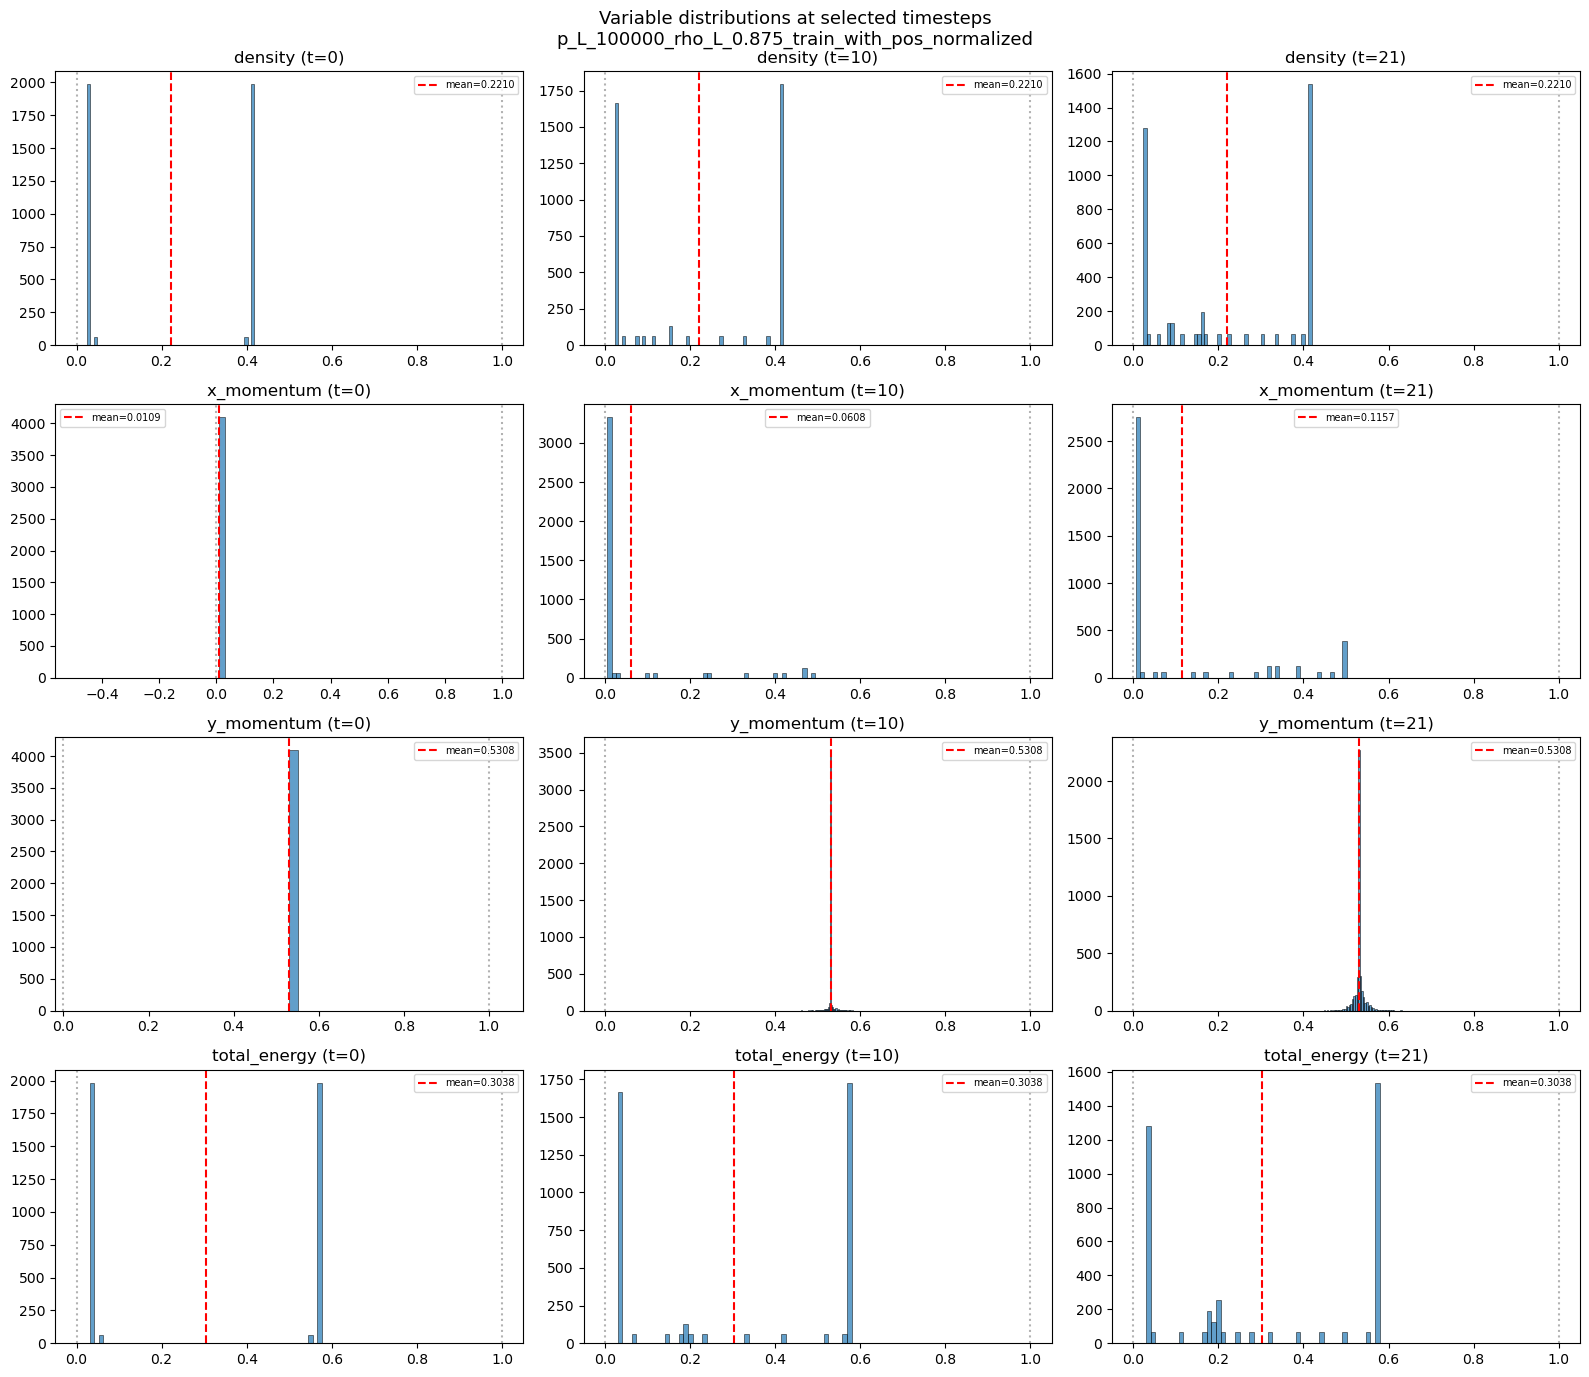

=== Value ranges across ALL timesteps ===
  density        : [0.023954, 0.419534] ✅
  x_momentum     : [0.005363, 0.514538] ✅
  y_momentum     : [0.401413, 0.676438] ✅
  total_energy   : [0.030114, 0.580324] ✅


In [5]:
# === Dynamic variable distributions at different timesteps ===
var_names = ['density', 'x_momentum', 'y_momentum', 'total_energy']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
timesteps = [0, len(sim)//4, len(sim)//2]

for col, t in enumerate(timesteps):
    d = sim[t]
    dynamic = d.x[:, 2:]
    
    for row, name in enumerate(var_names):
        ax = axes[row, col]
        vals = dynamic[:, row].numpy()
        ax.hist(vals, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.set_title(f'{name} (t={t})')
        ax.axvline(vals.mean(), color='r', linestyle='--', label=f'mean={vals.mean():.4f}')
        ax.axvline(0, color='k', linestyle=':', alpha=0.3)
        ax.axvline(1, color='k', linestyle=':', alpha=0.3)
        ax.legend(fontsize=7)

plt.suptitle(f'Variable distributions at selected timesteps\n{sim_files[0].stem}', fontsize=13)
plt.tight_layout()
plt.show()

# Check value ranges
print("=== Value ranges across ALL timesteps ===")
all_mins = torch.full((4,), float('inf'))
all_maxs = torch.full((4,), float('-inf'))
for t in range(len(sim)):
    dyn = sim[t].x[:, 2:]
    all_mins = torch.min(all_mins, dyn.min(dim=0).values)
    all_maxs = torch.max(all_maxs, dyn.max(dim=0).values)

for i, name in enumerate(var_names):
    in_range = 0 <= all_mins[i] and all_maxs[i] <= 1
    flag = "✅" if in_range else "⚠️  OUT OF [0,1]"
    print(f"  {name:15s}: [{all_mins[i]:.6f}, {all_maxs[i]:.6f}] {flag}")


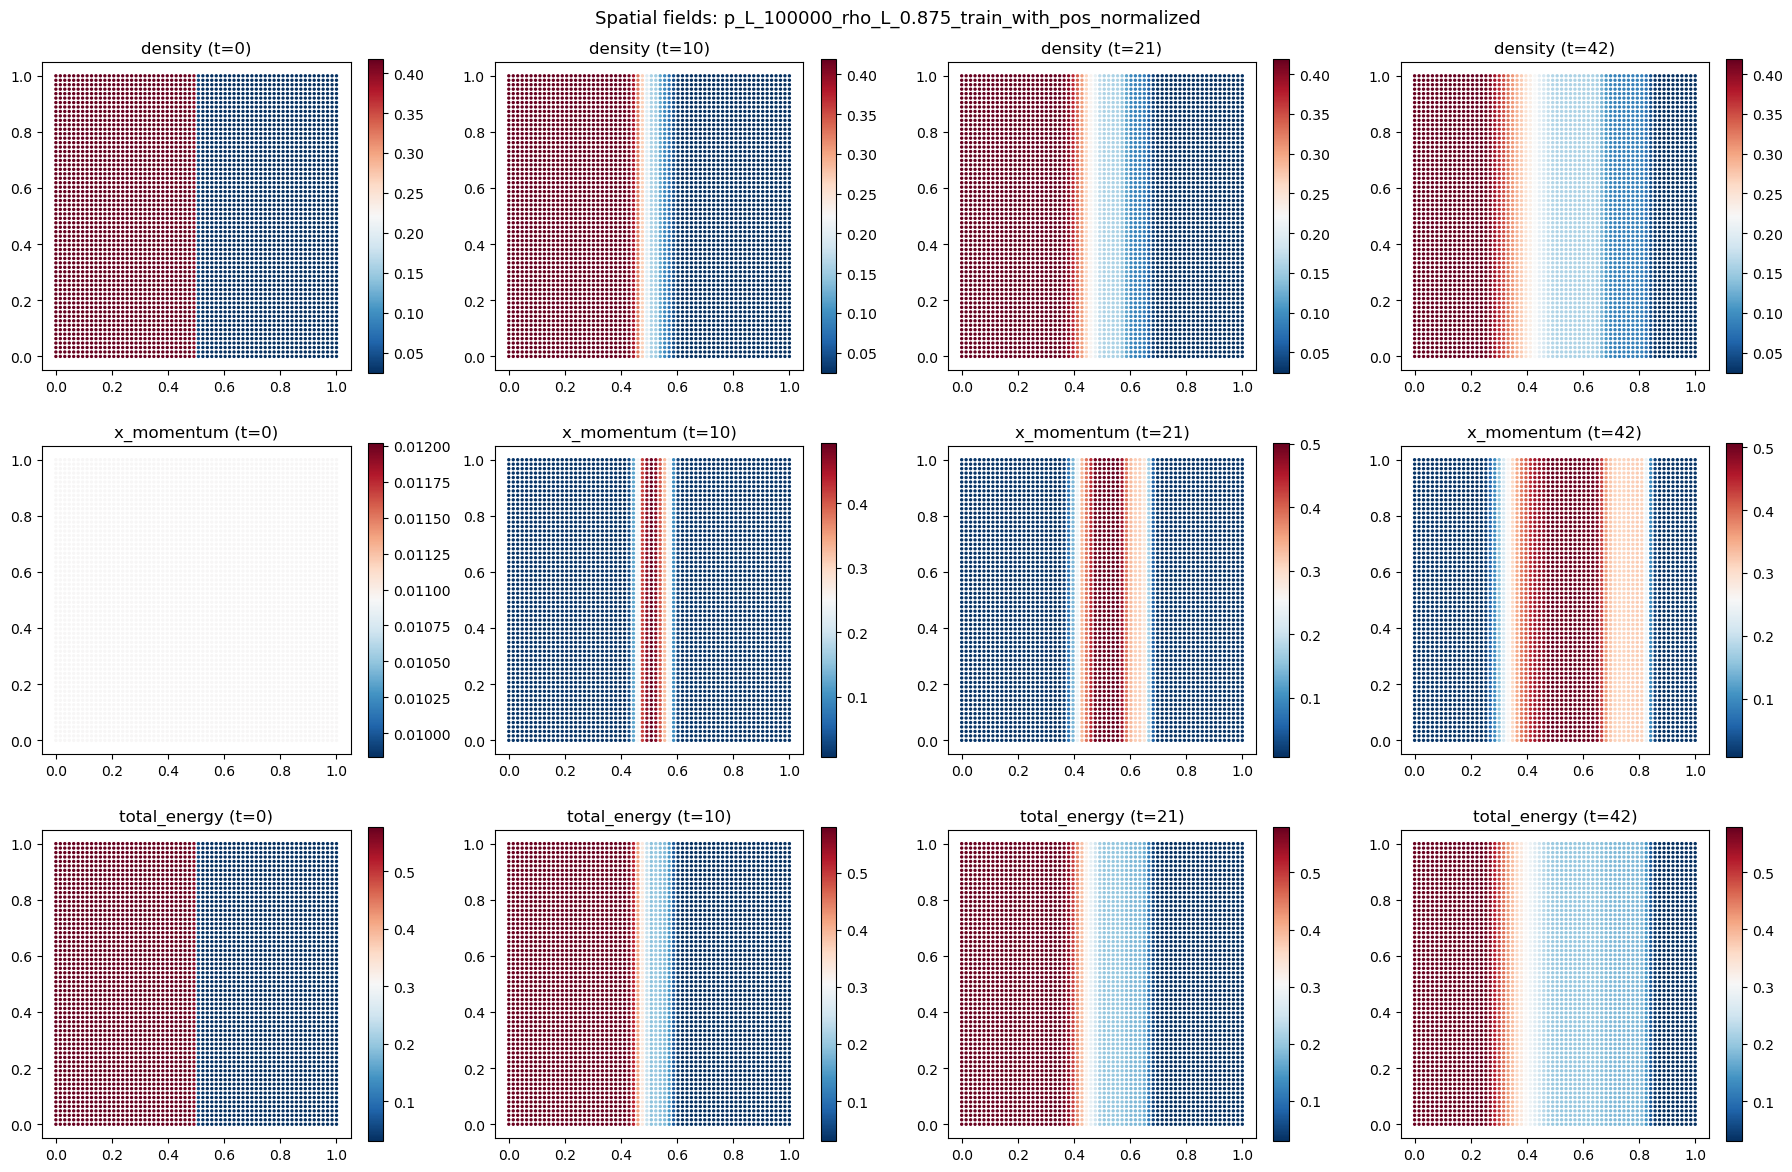

In [6]:
# === Spatial fields: verify shock structure ===
pos = sim[0].x[:, :2]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
timesteps = [0, len(sim)//4, len(sim)//2, len(sim)-1]
plot_vars = [0, 1, 3]  # density, x_mom, energy (skip y_mom)
plot_names = ['density', 'x_momentum', 'total_energy']

for col, t in enumerate(timesteps):
    dyn = sim[t].x[:, 2:]
    for row, (vi, vname) in enumerate(zip(plot_vars, plot_names)):
        ax = axes[row, col]
        vals = dyn[:, vi].numpy()
        sc = ax.scatter(pos[:, 0].numpy(), pos[:, 1].numpy(), c=vals, s=2, cmap='RdBu_r')
        plt.colorbar(sc, ax=ax, fraction=0.046)
        ax.set_title(f'{vname} (t={t})')
        ax.set_aspect('equal')

plt.suptitle(f'Spatial fields: {sim_files[0].stem}', fontsize=13)
plt.tight_layout()
plt.show()


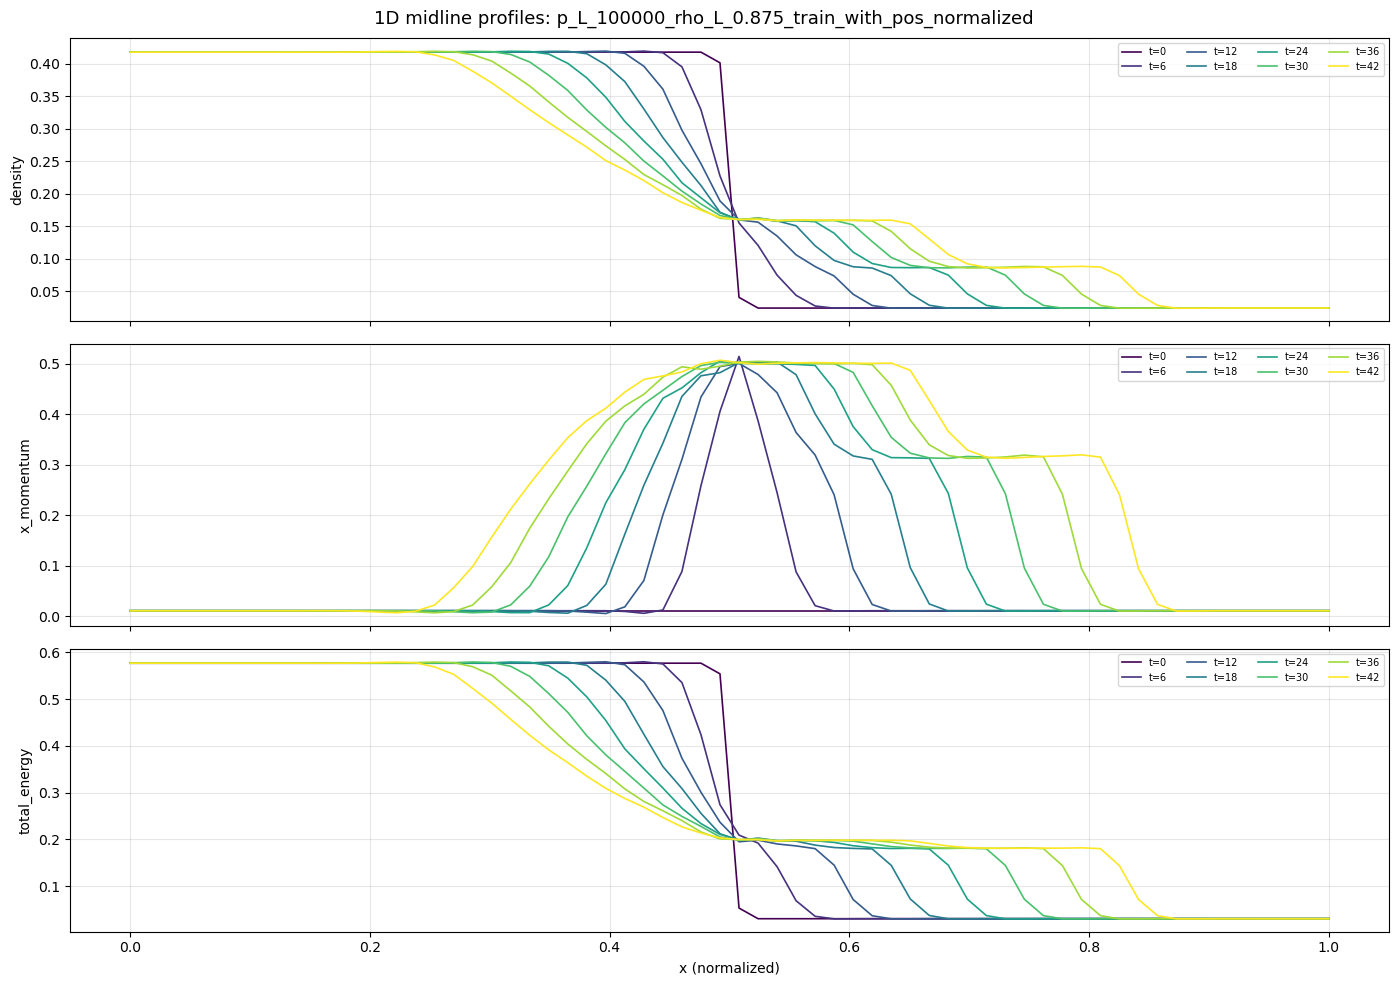

In [7]:
# === 1D midline slices (should show clean shock profile) ===
pos = sim[0].x[:, :2]
mid_y = pos[:, 1].median()
y_tol = (pos[:, 1].max() - pos[:, 1].min()) / 64 * 0.6
mid_mask = (pos[:, 1] - mid_y).abs() < y_tol
x_mid = pos[mid_mask, 0].numpy()
sort_idx = np.argsort(x_mid)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
plot_vars = [0, 1, 3]
plot_names = ['density', 'x_momentum', 'total_energy']
colors = plt.cm.viridis(np.linspace(0, 1, min(len(sim), 8)))

for ax, vi, vname in zip(axes, plot_vars, plot_names):
    for i, t in enumerate(np.linspace(0, len(sim)-1, min(len(sim), 8), dtype=int)):
        dyn = sim[t].x[:, 2:]
        vals = dyn[mid_mask, vi].numpy()
        ax.plot(x_mid[sort_idx], vals[sort_idx], color=colors[i], label=f't={t}', linewidth=1.2)
    ax.set_ylabel(vname)
    ax.legend(fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('x (normalized)')
plt.suptitle(f'1D midline profiles: {sim_files[0].stem}', fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
# === What the training loop actually feeds the model ===
# Reproduce the data loading logic from ShockTubeRolloutDataset + train_gparcv2.py

d0 = sim[0]
print("=== Raw Data Object ===")
print(f"x shape: {d0.x.shape}  → [pos_x, pos_y, density, x_mom, y_mom, energy]")
print(f"y shape: {d0.y.shape}  → [density, x_mom, y_mom, energy]")

# Training script extracts:
num_static = 2
skip_indices = [2]  # y_momentum
num_raw_dynamic = 4

static = d0.x[:, :num_static]
raw_dynamic = d0.x[:, num_static:num_static + num_raw_dynamic]
keep = [i for i in range(num_raw_dynamic) if i not in skip_indices]
used_dynamic = raw_dynamic[:, keep]

print(f"\n=== After skip_dynamic_indices={skip_indices} ===")
print(f"  static shape: {static.shape}  (pos_x, pos_y)")
print(f"  used_dynamic: {used_dynamic.shape}  (density, x_mom, energy)")
print(f"  Used indices: {keep} → names: {[meta['target_layout'][i] for i in keep]}")

# Targets
raw_targets = d0.y
used_targets = raw_targets[:, keep]
print(f"\n=== Targets ===")
print(f"  raw y shape: {raw_targets.shape}")
print(f"  used y shape: {used_targets.shape}")

# Global attrs
print(f"\n=== Global Attrs ===")
if hasattr(d0, 'global_params'):
    gp = d0.global_params
    print(f"  global_params: {gp.tolist()}")
    print(f"  Layout: {meta['global_param_layout']}")
    
    # The model reads: global_pressure, global_density, global_delta_t
    # But the dataset stores them in global_params[0,1,2]
    # The ShockTubeRolloutDataset splits them into data.global_pressure, etc.
    print(f"\n  After dataset splitting:")
    print(f"    global_pressure = {gp[0].item():.6f}")
    print(f"    global_density  = {gp[1].item():.6f}")
    print(f"    global_delta_t  = {gp[2].item():.6f}")
    
    # The model._extract_global_attrs reads [pressure, density, delta_t]
    # and processes them through GlobalParameterProcessor
    print(f"\n  → These get embedded to global_embed[64]")
    print(f"  → And passed as raw_global_attrs[3] to FiLM layers")

# Denormalize to physical values
print(f"\n=== Physical values (denormalized) ===")
norm = meta['normalization_params']
for i, name in enumerate(meta['feature_layout'][2:]):  # skip pos
    nmin = norm[name]['min']
    nmax = norm[name]['max']
    vals = raw_dynamic[:, i]
    phys_min = vals.min().item() * (nmax - nmin) + nmin
    phys_max = vals.max().item() * (nmax - nmin) + nmin
    phys_mean = vals.mean().item() * (nmax - nmin) + nmin
    print(f"  {name:15s}: norm=[{vals.min():.4f}, {vals.max():.4f}] → phys=[{phys_min:.4f}, {phys_max:.4f}]")


=== Raw Data Object ===
x shape: torch.Size([4096, 6])  → [pos_x, pos_y, density, x_mom, y_mom, energy]
y shape: torch.Size([4096, 4])  → [density, x_mom, y_mom, energy]

=== After skip_dynamic_indices=[2] ===
  static shape: torch.Size([4096, 2])  (pos_x, pos_y)
  used_dynamic: torch.Size([4096, 3])  (density, x_mom, energy)
  Used indices: [0, 1, 3] → names: ['density', 'x_momentum', 'total_energy']

=== Targets ===
  raw y shape: torch.Size([4096, 4])
  used y shape: torch.Size([4096, 3])

=== Global Attrs ===
  global_params: [0.42105263471603394, 0.25, 0.2686622738838196]
  Layout: ['pressure', 'density_param', 'delta_t']

  After dataset splitting:
    global_pressure = 0.421053
    global_density  = 0.250000
    global_delta_t  = 0.268662

  → These get embedded to global_embed[64]
  → And passed as raw_global_attrs[3] to FiLM layers

=== Physical values (denormalized) ===
  density        : norm=[0.0243, 0.4178] → phys=[0.1094, 0.8750]
  x_momentum     : norm=[0.0109, 0.0109] →

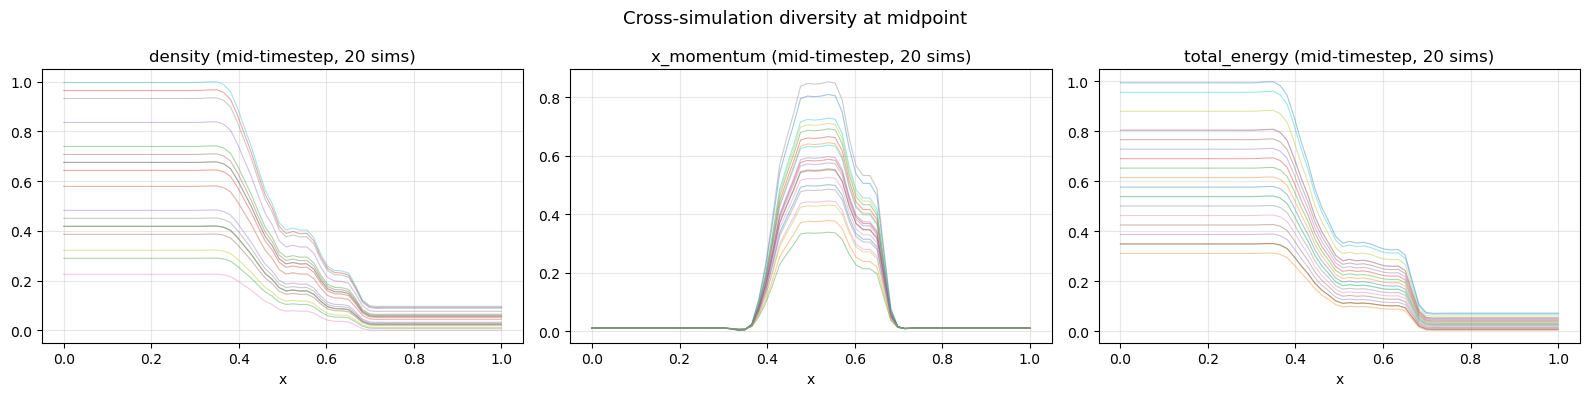

=== Step-to-step changes (Δ per timestep) ===

  p_L_100000_rho_L_0.875_train_with_pos_no:
    density        : mean|Δ|=0.00161005, max|Δ|=0.00166955
    x_momentum     : mean|Δ|=0.00521989, max|Δ|=0.00539264
    y_momentum     : mean|Δ|=0.00305144, max|Δ|=0.00658658
    total_energy   : mean|Δ|=0.00257536, max|Δ|=0.00288536

  p_L_162500_rho_L_1.5_train_with_pos_norm:
    density        : mean|Δ|=0.00276009, max|Δ|=0.00286208
    x_momentum     : mean|Δ|=0.00871224, max|Δ|=0.00900057
    y_momentum     : mean|Δ|=0.00493667, max|Δ|=0.01076964
    total_energy   : mean|Δ|=0.00418495, max|Δ|=0.00468871


In [9]:
# === Variation across simulations ===
# Sample a few sims to check diversity

sample_indices = np.linspace(0, len(sim_files)-1, min(20, len(sim_files)), dtype=int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_vars = [0, 1, 3]
plot_names = ['density', 'x_momentum', 'total_energy']

for idx in sample_indices:
    s = torch.load(sim_files[idx], weights_only=False)
    d = s[len(s)//2]  # mid timestep
    dyn = d.x[:, 2:]
    x_vals = d.x[mid_mask, 0].numpy()
    si = np.argsort(x_vals)
    
    for ax, vi in zip(axes, plot_vars):
        vals = dyn[mid_mask, vi].numpy()
        ax.plot(x_vals[si], vals[si], alpha=0.4, linewidth=0.8)

for ax, name in zip(axes, plot_names):
    ax.set_title(f'{name} (mid-timestep, {len(sample_indices)} sims)')
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

plt.suptitle('Cross-simulation diversity at midpoint', fontsize=13)
plt.tight_layout()
plt.show()

# Delta magnitudes (what the model needs to predict)
print("=== Step-to-step changes (Δ per timestep) ===")
for idx in [0, len(sim_files)//2]:
    s = torch.load(sim_files[idx], weights_only=False)
    name = sim_files[idx].stem[:40]
    deltas = []
    for t in range(len(s)-1):
        d_curr = s[t].x[:, 2:]
        d_next = s[t+1].x[:, 2:]
        delta = (d_next - d_curr).abs().mean(dim=0)
        deltas.append(delta)
    deltas = torch.stack(deltas)
    
    print(f"\n  {name}:")
    for i, vname in enumerate(var_names):
        print(f"    {vname:15s}: mean|Δ|={deltas[:, i].mean():.8f}, max|Δ|={deltas[:, i].max():.8f}")
